In [1]:
import Pkg
Pkg.add("Optim")
Pkg.add("Plots")
Pkg.add("Printf")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
  Installing 2 artifacts
   Installed artifact GR                       19.0 MiB
   Installed artifact Ghostscript              31.4 MiB
    Updating `~/.julia/environments/v1.12/Project.toml`
  [91a5bcdd] + Plots v1.41.6
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [66dad0bd] + AliasTables v1.1.3
  [d1d4a3ce] + BitFlags v0.1.9
  [944b1d66] + CodecZlib v0.7.8
  [35d6a980] + ColorSchemes v3.31.0
  [3da002f7] + ColorTypes v0.12.1
  [c3611d14] + ColorVectorSpace v0.11.0
  [5ae59095] + Colors v0.13.1
  [f0e56b4a] + ConcurrentUtilities v2.5.1
  [d38c429a] + Contour v0.6.3
  [9a962f9c] + DataAPI v1.16.0
  [864edb3b] + DataStructures v0.19.3
  [8bb1440f] + DelimitedFiles v1.9.1
  [ffbed154] + DocStringExtensions v0.9.5
  [460bff9d

In [2]:
using LinearAlgebra

In [3]:
using Optim
using Plots
using Printf

In [4]:
function barrier_method_1d(f, gs, x0;
    r_vec0::Vector{Float64},
    r_factor=10.0,
    tol=1e-6,
    max_iter=100,
    opt_iterations=2000)

    # x0 must be a 1-element vector [x]
    if all(g(x0) >= 0 for g in gs)
        error("Initial point is infeasible (constraint violated)")
    end

    const_ε = 1e-12
    history = [copy(x0)]
    x = copy(x0)
    r_vec = copy(r_vec0)

    for _ in 1:max_iter
        function Q(pt)
            all(g(pt) >= 0 for g in gs) && return Inf
            val = f(pt)
            for (i, g) in enumerate(gs)
                gv = g(pt)
                if gv < 0 && r_vec[i] > const_ε
                    val += (1.0 / r_vec[i]) * (-1.0 / gv)
                end
            end
            return val
        end

        result = optimize(Q, x, NelderMead(), Optim.Options(iterations=opt_iterations))
        x_new = result.minimizer
        push!(history, copy(x_new))

        norm(x_new - x) < tol && break

        x = x_new
        r_vec .*= r_factor
    end

    return history
end

barrier_method_1d (generic function with 1 method)

In [3]:
# Одномерная функция f(x) = x²
# Ограничение: x >= 1  (оптимум при x=1, f=1)
f(x)  = x[1]^2
g1(x) = 1.0 - x[1]   # x >= 1
gs = [g1]

x0 = [3.0]
@printf("Начальная точка: x0 = %.1f,  f(x0) = %.1f\n", x0[1], f(x0))

Начальная точка: x0 = 3.0,  f(x0) = 9.0


In [6]:
# Разные начальные r для барьерного метода
r_vec0_list = [[0.5], [1.0], [2.0]]

results = [
    barrier_method_1d(f, gs, x0; r_vec0=rv, r_factor=10.0, tol=1e-6)
    for rv in r_vec0_list
]

println("Результаты (оптимум: x=1, f=1):")
for (i, traj) in enumerate(results)
    x_fin = traj[end][1]
    n_steps = length(traj) - 1
    @printf("  r₀=%.1f  →  x=%.4f  f=%.4f  (%d шагов)\n",
        r_vec0_list[i][1], x_fin, f(traj[end]), n_steps)
end

Результаты (оптимум: x=1, f=1):
  r₀=0.5  →  x=1.0000  f=1.0000  (14 шагов)
  r₀=1.0  →  x=1.0000  f=1.0000  (14 шагов)
  r₀=2.0  →  x=1.0000  f=1.0000  (14 шагов)


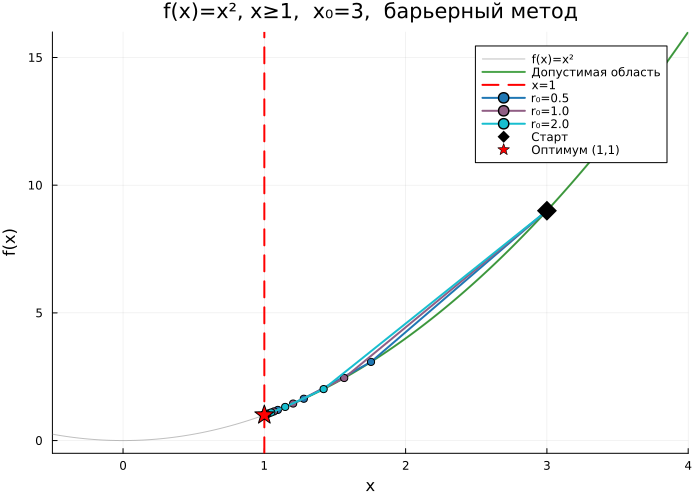

In [7]:
# Визуализация: f(x)=x², допустимая область x>=1, траектории
let
    xg = range(-0.5, 4.0, length=300)
    yg = [x >= 1 ? x^2 : NaN for x in xg]  # f только в допустимой области

    p = plot(
        title="f(x)=x², x≥1,  x₀=3,  барьерный метод",
        xlabel="x", ylabel="f(x)",
        xlims=(-0.5, 4.0), ylims=(-0.5, 16),
        size=(700, 500),
        legend=:topright,
    )

    # Кривая f(x)=x² (вся)
    plot!(p, xg, xg.^2, lw=1, c=:gray, alpha=0.5, label="f(x)=x²")

    # Допустимая область (x>=1)
    plot!(p, xg, yg, lw=2, c=:green, alpha=0.7, label="Допустимая область")

    # Вертикальная линия x=1
    vline!(p, [1.0], lw=2, ls=:dash, c=:red, label="x=1")

    # Траектории
    traj_colors = palette(:tab10, length(results))
    for (i, traj) in enumerate(results)
        xs = [pt[1] for pt in traj]
        ys = [pt[1]^2 for pt in traj]
        plot!(p, xs, ys, lw=2, c=traj_colors[i],
            marker=:circle, ms=4, label="r₀=$(r_vec0_list[i][1])")
    end

    # Начальная точка
    scatter!(p, [x0[1]], [f(x0)], ms=10, marker=:diamond, c=:black, label="Старт")

    # Оптимум
    scatter!(p, [1.0], [1.0], ms=10, marker=:star5, c=:red, label="Оптимум (1,1)")

    display(p)
end